# Prediksi Harga Beras, Cabai Rawit, dan Bawang Merah di Provinsi DI Yogyakarta

Prediksi harga harian: LightGBM + Genetic Algorithm.


## 1. Import Library

Library data, visualisasi, ADF, LightGBM, skforecast, dan PyGAD.


In [1]:
import warnings

import joblib as jl
import lightgbm as lgb
import matplotlib.pyplot as plt
import missingno as mgno
import numpy as np
import pandas as pd
import pygad
import seaborn as sns
from skforecast.direct import ForecasterDirect
from skforecast.exceptions import IgnoredArgumentWarning, LongTrainingWarning
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.preprocessing import CalendarFeatures, RollingFeatures
from skforecast.utils import save_forecaster
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit
from sktime.forecasting.trend import TrendForecaster
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

/home/yosiacokr/Documents/Project/pangan-forecasting/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning, module="sktime")
warnings.simplefilter("ignore", category=IgnoredArgumentWarning)
warnings.simplefilter("ignore", category=LongTrainingWarning)

## 2. Exploratory Data Analysis (EDA)

Cek struktur, sebaran, korelasi, dan missing value.


### 2.1 Memuat Dataset (CSV)

Baca `DATASET-BERAS.csv` ke `df_raw`.


In [3]:
df_raw = pd.read_csv("DATASET-BERAS.csv")
df_raw.head()

,tanggal,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Bawang Merah Ukuran Sedang,Cabai Rawit Hijau,Cabai Rawit Merah
0,2021-01-04,10.4,9.9,11.75,11.0,12.75,12.4,32.25,56.25,62.50
1,2021-01-05,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.25,68.75
2,2021-01-06,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.25,68.75
3,2021-01-07,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.00,71.25
4,2021-01-08,10.4,9.9,11.75,11.0,12.75,12.4,31.75,56.00,71.25


### 2.2 Mengubah dan Menetapkan Indeks Tanggal

Kolom `tanggal` jadi DatetimeIndex harian.


In [4]:
df_raw.index = pd.DatetimeIndex(df_raw["tanggal"], yearfirst=True)
df_raw.drop(columns=["tanggal"], inplace=True)
df_raw = df_raw.asfreq("D")

### 2.3 Memeriksa Informasi dan Tipe Data

Cek dimensi, tipe, dan jumlah non-null.


In [5]:
df_raw.shape
df_raw.info()
df_raw.dtypes

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2038 entries, 2021-01-04 to 2026-08-03
Freq: D
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Beras Kualitas Bawah I      1427 non-null   float64
 1   Beras Kualitas Bawah II     1427 non-null   float64
 2   Beras Kualitas Medium I     1427 non-null   float64
 3   Beras Kualitas Medium II    1427 non-null   float64
 4   Beras Kualitas Super I      1427 non-null   float64
 5   Beras Kualitas Super II     1427 non-null   float64
 6   Bawang Merah Ukuran Sedang  1427 non-null   float64
 7   Cabai Rawit Hijau           1427 non-null   float64
 8   Cabai Rawit Merah           1427 non-null   float64
dtypes: float64(9)
memory usage: 159.2 KB


Beras Kualitas Bawah I        float64
Beras Kualitas Bawah II       float64
Beras Kualitas Medium I       float64
Beras Kualitas Medium II      float64
Beras Kualitas Super I        float64
Beras Kualitas Super II       float64
Bawang Merah Ukuran Sedang    float64
Cabai Rawit Hijau             float64
Cabai Rawit Merah             float64
dtype: object

### 2.4 Visualisasi Distribusi dan Outlier (Boxplot)

Boxplot sebaran dan outlier tiap komoditas.


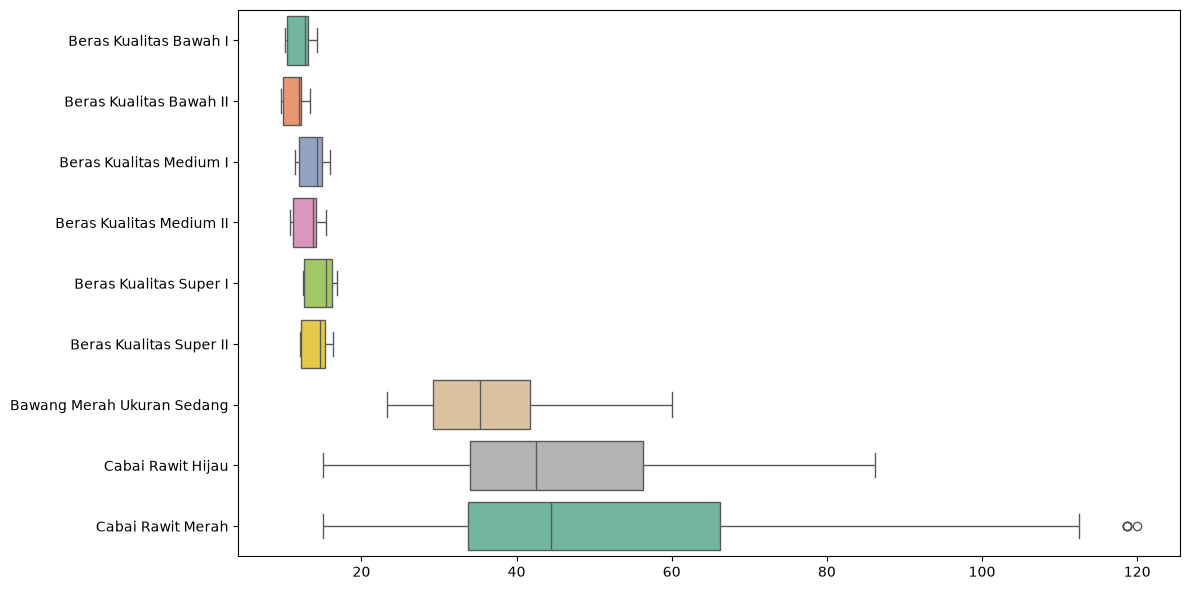

In [6]:
nums_cols = df_raw.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_raw[nums_cols], orient="h", palette="Set2", showfliers=True, whis=1.5
)
plt.tight_layout()
plt.show()

### 2.5 Matriks Korelasi

Heatmap korelasi antar harga.


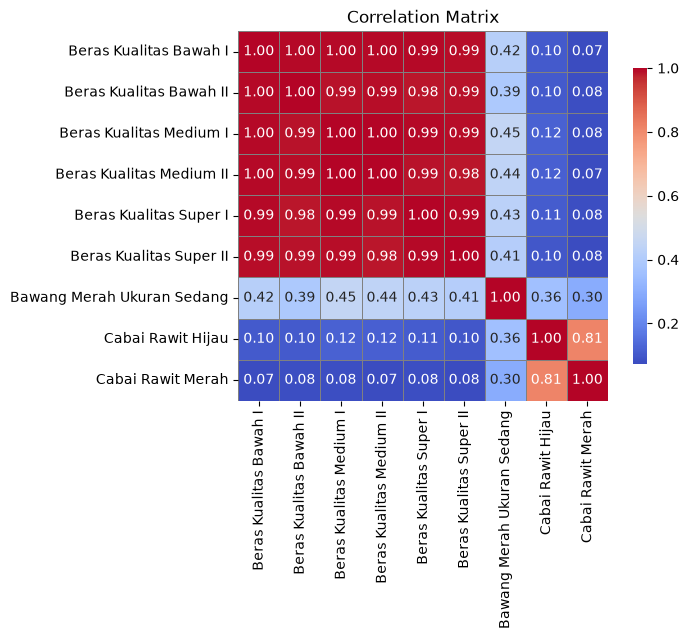

In [7]:
matrix_corr = df_raw[nums_cols].corr()
sns.heatmap(
    matrix_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Correlation Matrix")
plt.show()

### 2.6 Memeriksa Missing Value (Heatmap)

Letak nilai kosong di data.


Text(0, 0.5, 'Jumlah Data (Persen)')

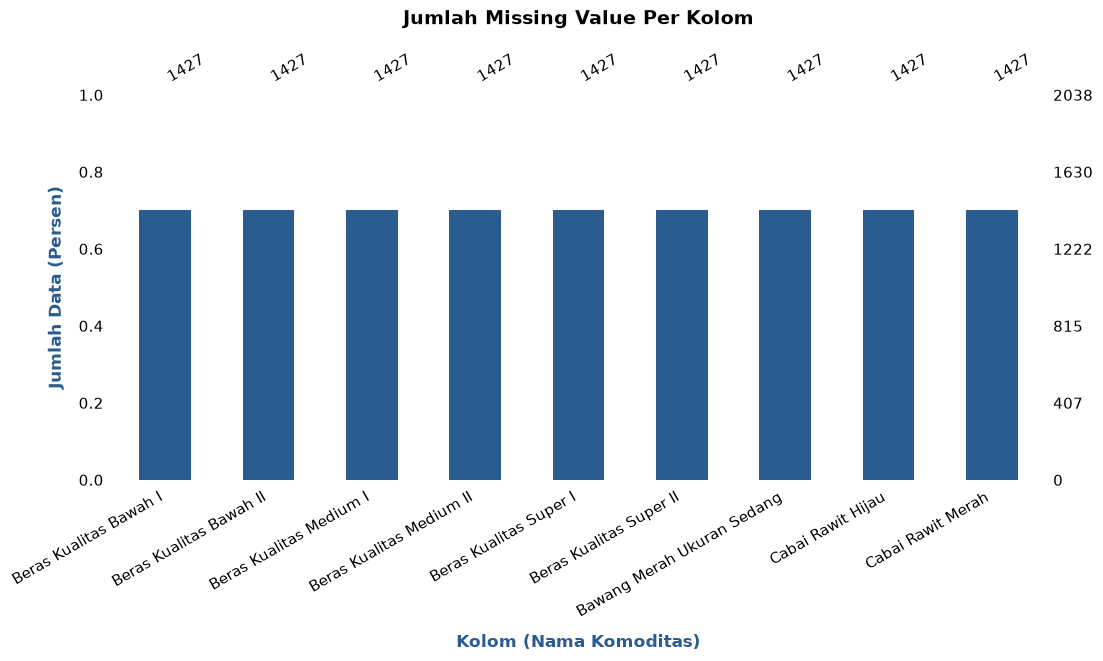

In [8]:
df_raw.isnull().sum()

ax = mgno.bar(
    df_raw,
    figsize=(12, 5),
    fontsize=11,
    labels=True,
    sort="ascending",
    p=True,
    color="#2b5c8f",
    label_rotation=30,
)

ax.set_title("Jumlah Missing Value Per Kolom", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel(
    "Kolom (Nama Komoditas)",
    fontsize=12,
    labelpad=10,
    fontweight="bold",
    color="#2b5c8f",
)
ax.set_ylabel(
    "Jumlah Data (Persen)", fontsize=12, labelpad=10, fontweight="bold", color="#2b5c8f"
)

### 2.7 Memeriksa Persentase Missing Value

Persen missing tiap kolom.


In [9]:
percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
print(percentages)

Beras Kualitas Bawah I        29.980373
Beras Kualitas Bawah II       29.980373
Beras Kualitas Medium I       29.980373
Beras Kualitas Medium II      29.980373
Beras Kualitas Super I        29.980373
Beras Kualitas Super II       29.980373
Bawang Merah Ukuran Sedang    29.980373
Cabai Rawit Hijau             29.980373
Cabai Rawit Merah             29.980373
dtype: float64


## 3. Penanganan Missing Value dengan Interpolasi

Isi gap dengan interpolasi waktu. Jumlah baris tetap.


### 3.1 Interpolasi Berbasis Waktu

`method="time"` mengisi gap mengikuti jarak tanggal.


In [10]:
feature_interpolation = df_raw.interpolate(
    method="time", limit_direction="forward", axis=0
)

### 3.2 Menetapkan `df_cleaned` dan Memeriksa Missing Value

Hasil interpolasi disimpan ke `df_cleaned`.


In [11]:
df_cleaned = feature_interpolation
print(df_cleaned.isnull().sum())

Beras Kualitas Bawah I        0
Beras Kualitas Bawah II       0
Beras Kualitas Medium I       0
Beras Kualitas Medium II      0
Beras Kualitas Super I        0
Beras Kualitas Super II       0
Bawang Merah Ukuran Sedang    0
Cabai Rawit Hijau             0
Cabai Rawit Merah             0
dtype: int64


### 3.3 Memeriksa Persentase Missing Value Setelah Interpolasi

Pastikan missing sudah 0%.


In [12]:
feature_miss_value = df_cleaned.isnull().sum() * 100 / len(df_cleaned)
print(feature_miss_value)

Beras Kualitas Bawah I        0.0
Beras Kualitas Bawah II       0.0
Beras Kualitas Medium I       0.0
Beras Kualitas Medium II      0.0
Beras Kualitas Super I        0.0
Beras Kualitas Super II       0.0
Bawang Merah Ukuran Sedang    0.0
Cabai Rawit Hijau             0.0
Cabai Rawit Merah             0.0
dtype: float64


### 3.4 Visualisasi Missing Value Setelah Interpolasi (Heatmap)

Cek visual: missing sudah tidak ada.


Text(0, 0.5, 'Jumlah Data (Persen)')

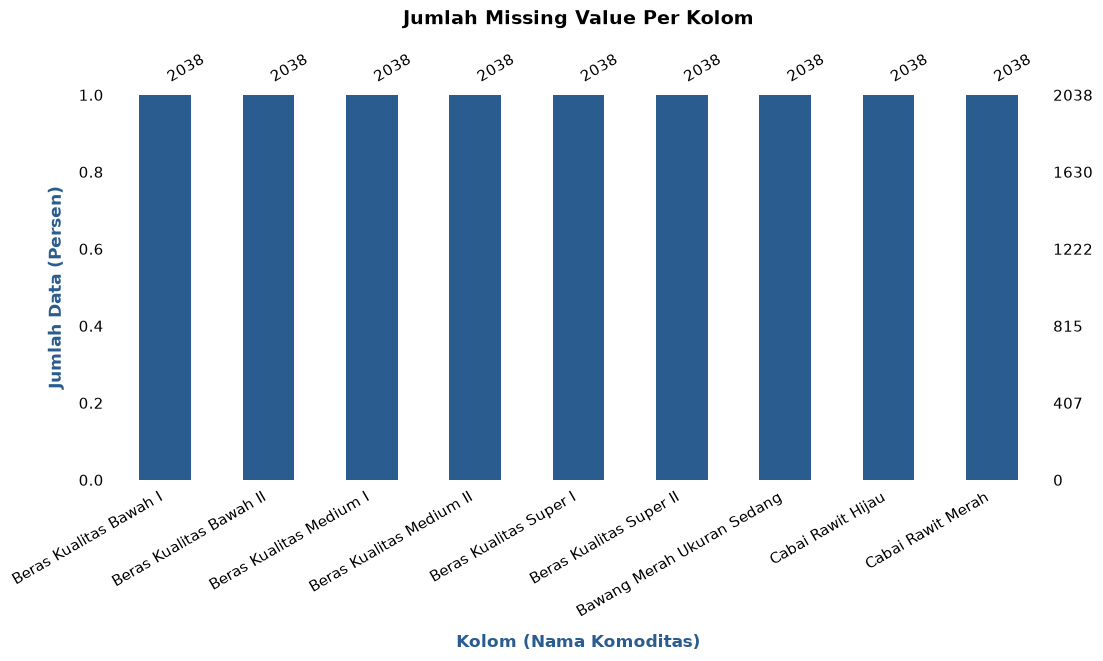

In [13]:
df_cleaned.isnull().sum()

ax = mgno.bar(
    df_cleaned,
    figsize=(12, 5),
    fontsize=11,
    labels=True,
    sort="ascending",
    p=True,
    color="#2b5c8f",
    label_rotation=30,
)

ax.set_title("Jumlah Missing Value Per Kolom", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel(
    "Kolom (Nama Komoditas)",
    fontsize=12,
    labelpad=10,
    fontweight="bold",
    color="#2b5c8f",
)
ax.set_ylabel(
    "Jumlah Data (Persen)", fontsize=12, labelpad=10, fontweight="bold", color="#2b5c8f"
)


## 4. Uji Stasioneritas (ADF Test)

p-value < 0.05 = stasioner. Dasar MSTL di bab 5.


### 4.1 Menentukan Daftar Kolom Komoditas

Nama kolom komoditas disimpan di `comodity_cols`.


In [14]:
comodity_cols = df_cleaned.columns.tolist()

### 4.2 ADF Test dengan Trend dan Konstanta (`regression="ct"`)

Uji stasioner dengan konstanta dan tren.


In [15]:
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="ct",
        autolag="AIC",
        store=False,
        regresults=False,
        result_object=False,
    )

    print(f"ADF Statistic for {col}: {result[0]}")
    print(f"p-value for {col}: {result[1]}")
    if len(result) > 4:
        critical_values = result[4]
        print("Critical Values for: ")
        for key, value in critical_values.items():
            print(f"\t{key}: {value}")
    else:
        critical_values = {}
    status = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    print(f"status : {status}")
    print("\n")

ADF Statistic for Beras Kualitas Bawah I: -1.1808364979181016
p-value for Beras Kualitas Bawah I: 0.9143563466248104
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualitas Bawah II: -1.0090015757098951
p-value for Beras Kualitas Bawah II: 0.9428908749249455
Critical Values for: 
	1%: -3.9632321666575834
	5%: -3.412652823739877
	10%: -3.128323394200126
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium I: -1.6561424262773188
p-value for Beras Kualitas Medium I: 0.7696836037691597
Critical Values for: 
	1%: -3.963278836113111
	5%: -3.4126754323752686
	10%: -3.1283367017897814
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium II: -1.3309686501490685
p-value for Beras Kualitas Medium II: 0.8800549244162332
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualita

### 4.3 Visualisasi Status Stasioneritas

Hijau = stasioner, oranye = belum.


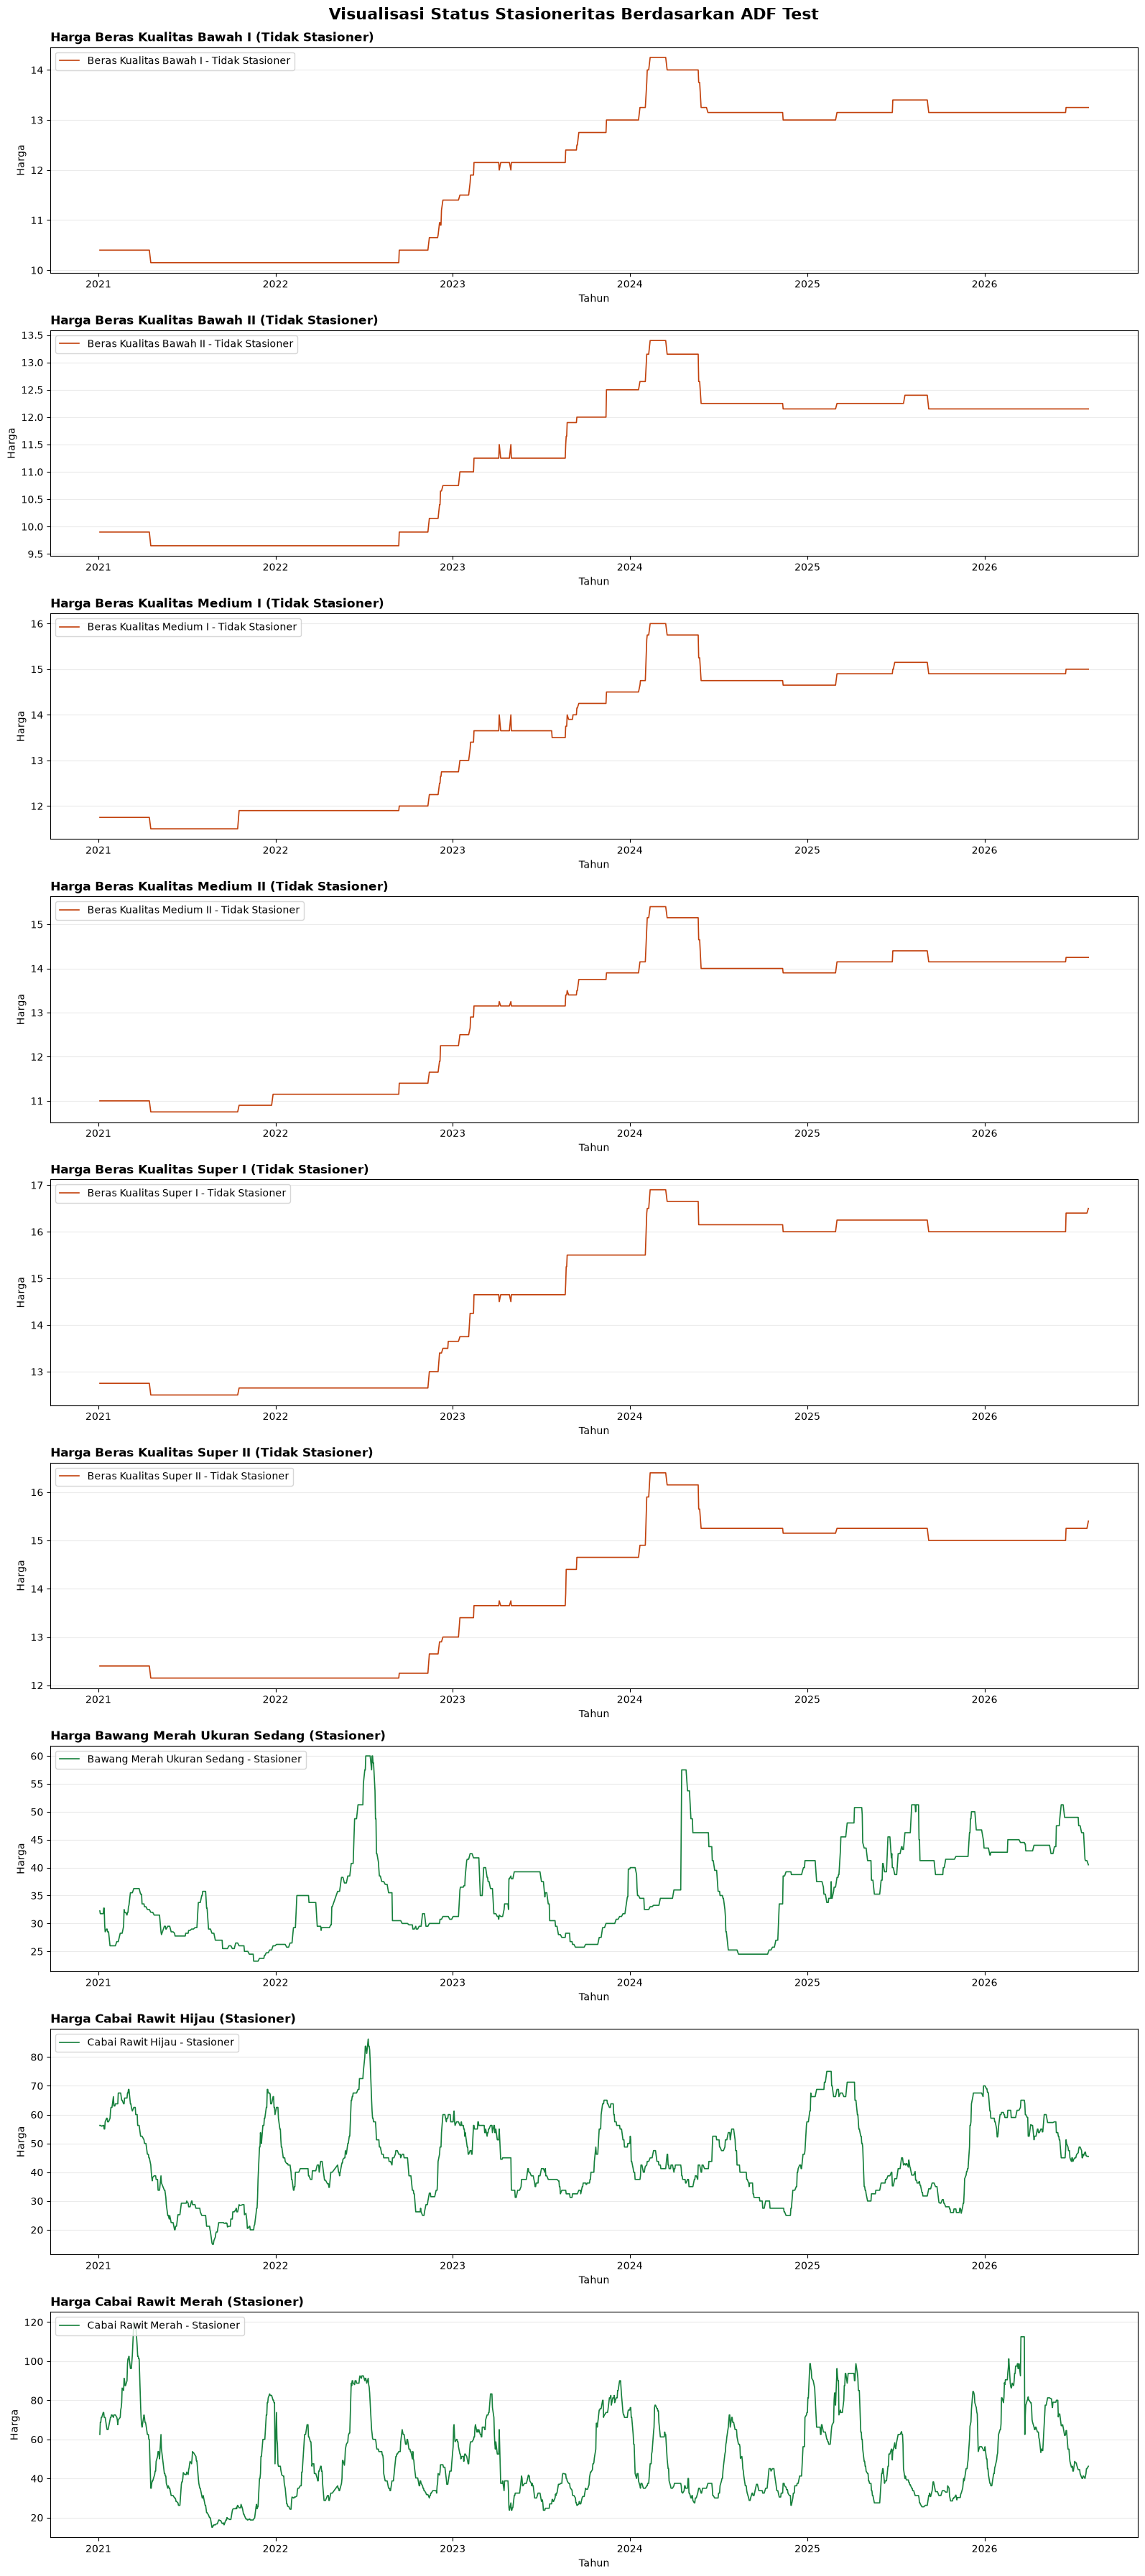

In [16]:
stasionery_status = {}
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="ct",
        autolag="AIC",
        store=False,
        regresults=False,
        result_object=False,
    )
    stasionery_status[col] = "Stasioner" if result[1] < 0.05 else "Tidak Stasioner"

fig_size = (16, 4 * len(comodity_cols))

fig, axes = plt.subplots(
    nrows=len(comodity_cols),
    ncols=1,
    figsize=fig_size,
)

for ax, col in zip(axes, comodity_cols):
    status = stasionery_status[col]
    color = "#16803c" if status == "Stasioner" else "#c2410c"

    ax.plot(
        df_cleaned.index,
        df_cleaned[col],
        color=color,
        linewidth=1.2,
        label=f"{col} - {status}",
    )
    ax.set_title(f"Harga {col} ({status})", loc="left", fontsize=12, fontweight="bold")
    ax.set_ylabel("Harga")
    ax.set_xlabel("Tahun")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left")

fig.suptitle(
    "Visualisasi Status Stasioneritas Berdasarkan ADF Test",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
fig.subplots_adjust(hspace=0.6, top=0.97)
plt.tight_layout()

plt.show()

## 5. Detrending dan Deseasonalization dengan Dekomposisi MSTL

MSTL pecah harga jadi trend, musiman (7 & 365), dan residual. Model jalan di residual. Fit hanya di **train**.


### 5.1 Mendekomposisi Trend, Seasonal, dan Residual Setiap Komoditas

MSTL per komoditas di train (test 60 hari dikunci). Trend diekstrapolasi; seasonal di-tile dari train.


In [17]:
df_cleaned["time_index"] = np.arange(len(df_cleaned))
trend_model = {}
seasonal_model = {}
decomp_by_col = {}
residual_splits = {}

paras_mstl = {
    "periods": 7,
    "stl_kwargs": {"robust": True},
}

holdout = TimeSeriesSplit(
    n_splits=5, test_size=60, max_train_size=int(len(df_cleaned) * 0.8)
)


def holdout_split_series(y):
    train_idx, test_idx = list(holdout.split(y))[-1]
    return y.iloc[train_idx], y.iloc[test_idx]


def fit_train_decomposition(price_train):
    mstl = MSTL(price_train, **paras_mstl).fit()
    residual_train = pd.Series(
        mstl.resid.values, index=price_train.index, name=price_train.name
    )
    trend_forecaster = ExponentialSmoothing(damped_trend=True, trend="add")
    trend_forecaster.fit(
        pd.Series(mstl.trend.values, index=pd.RangeIndex(len(mstl.trend)))
    )
    return mstl, trend_forecaster, residual_train


def tile_last_cycle(values, period, n_steps):
    cycle = np.asarray(values, dtype=float)[-period:]
    reps = int(np.ceil(n_steps / period))
    return np.tile(cycle, reps)[:n_steps]


def reconstruct_harga_test(trend_forecaster, mstl, residual_pred, n_steps):
    residual_pred = np.asarray(residual_pred, dtype=float).ravel()[:n_steps]
    trend_pred = np.asarray(
        trend_forecaster.predict(fh=np.arange(1, n_steps + 1))
    ).ravel()[:n_steps]
    seasonal_weekly = tile_last_cycle(mstl.seasonal.values, 7, n_steps)
    return trend_pred + seasonal_weekly + residual_pred


for col in comodity_cols:
    price_train, price_test = holdout_split_series(df_cleaned[col])
    mstl, trend_forecaster, residual_train = fit_train_decomposition(price_train)

    seasonal_model[col] = mstl
    trend_model[col] = trend_forecaster
    decomp_by_col[col] = {
        "price_train": price_train,
        "price_test": price_test,
        "residual_train": residual_train,
        "mstl": mstl,
        "trend_forecaster": trend_forecaster,
    }
    residual_splits[col] = {"train": residual_train}

    for suffix in ("trend", "seasonal_weekly", "residual"):
        df_cleaned[f"{col}_{suffix}"] = np.nan

    train_idx = price_train.index
    df_cleaned.loc[train_idx, f"{col}_trend"] = mstl.trend.values
    df_cleaned.loc[train_idx, f"{col}_seasonal_weekly"] = mstl.seasonal.values
    df_cleaned.loc[train_idx, f"{col}_residual"] = mstl.resid.values

    print(
        f"{col}: train {price_train.index.min().date()} → {price_train.index.max().date()} | "
        f"test dikunci {price_test.index.min().date()} → {price_test.index.max().date()} "
    )


Beras Kualitas Bawah I: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Beras Kualitas Bawah II: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Beras Kualitas Medium I: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Beras Kualitas Medium II: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Beras Kualitas Super I: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Beras Kualitas Super II: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Bawang Merah Ukuran Sedang: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Cabai Rawit Hijau: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 
Cabai Rawit Merah: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03 


### 5.1.1 Memeriksa Struktur `df_cleaned` Setelah Dekomposisi

Komponen hanya terisi di train. Baris test = NaN.


In [18]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2038 entries, 2021-01-04 to 2026-08-03
Freq: D
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Beras Kualitas Bawah I                      2038 non-null   float64
 1   Beras Kualitas Bawah II                     2038 non-null   float64
 2   Beras Kualitas Medium I                     2038 non-null   float64
 3   Beras Kualitas Medium II                    2038 non-null   float64
 4   Beras Kualitas Super I                      2038 non-null   float64
 5   Beras Kualitas Super II                     2038 non-null   float64
 6   Bawang Merah Ukuran Sedang                  2038 non-null   float64
 7   Cabai Rawit Hijau                           2038 non-null   float64
 8   Cabai Rawit Merah                           2038 non-null   float64
 9   time_index                                  2038 non-null  

### 5.2 Menyimpan Model Trend dan Hasil MSTL

Simpan trend dan MSTL train-only ke `.pkl`.


In [19]:
jl.dump(trend_model, "models/trend_model.pkl")
jl.dump(seasonal_model, "models/seasonal_model.pkl")

['models/seasonal_model.pkl']

## 6. Feature Engineering (Fitur Lag dan Rolling)

Lag, rolling, dan kalender dibuat di dalam `ForecasterDirect`.


### 6.1 Fitur Rolling dan Kalender

Resep rolling (7 & 30 hari) dan kalender siklik. Lag **tidak** di sini; lag ditulis di `ForecasterDirect(..., lags=[1, 7, 30])` mulai cell 6.2.


In [20]:
horizons = [1, 7, 30]

window_features = RollingFeatures(
    stats=["mean", "mean", "std", "std", "min", "min", "max", "max"],
    window_sizes=[7, 30, 7, 30, 7, 30, 7, 30],
)
calendar_features = CalendarFeatures(
    features=["day_of_year", "day_of_week", "day_of_month", "month"],
    features_to_encode=["day_of_year", "day_of_month", "day_of_week", "month"],
    encoding="cyclical",
    max_values={
        "day_of_year": 365,
        "day_of_week": 6,
        "day_of_month": 31,
        "month": 12,
    },
)


### 6.2 Melatih ForecasterDirect per Komoditas dan Horizon

Fit residual train, horizon 1, 7, dan 30.


In [21]:
horizons = [1, 7, 30]
forecasters_default = {}

for col in comodity_cols:
    forecasters_default[col] = {}
    for h in horizons:
        forecaster_default = ForecasterDirect(
            estimator=lgb.LGBMRegressor(force_col_wise=True),
            lags=[1, 7, 30],
            steps=h,
            window_features=window_features,
            calendar_features=calendar_features,
        )
        forecaster_default.fit(y=decomp_by_col[col]["residual_train"])
        forecasters_default[col][h] = forecaster_default


[LightGBM] [Info] Total Bins 3233
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 19
[LightGBM] [Info] Start training from score -0.000194
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 1594, number of used features: 19
[LightGBM] [Info] Start training from score -0.000194
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 1594, number of used features: 19
[LightGBM] [Info] Start training from score -0.000194
[LightGBM] [Info] Total Bins 3231
[LightGBM] [Info] Number of data points in the train set: 1594, number of used features: 19
[LightGBM] [Info] Start training from score -0.000194
[LightGBM] [Info] Total Bins 3231
[LightGBM] [Info] Number of data points in the train set: 1594, number of used features: 19
[LightGBM] [Info] Start training from score -0.000194
[LightGBM] [Info] Total Bins 3231
[LightGBM] [Info] Number of data points in the train set: 1594, nu

## 7. Pencarian Hyperparameter LightGBM dengan Genetic Algorithm

GA cari params LightGBM per komoditas × horizon.


### 7.1 Fitness Function dan Konfigurasi GA (PyGAD)

GA hanya lihat residual train. Fitness: TimeSeriesSplit 3 fold.


In [22]:
def running_for_ga(y, steps, window_features, calendar_features):
    genetic_algorithm_search_split = TimeSeriesSplit(
        n_splits=4, test_size=steps, max_train_size=1630
    )

    def fitness_function(ga_instance, solution, solution_idx):
        params = {
            "objective": "huber",
            "num_leaves": int(solution[0]),
            "learning_rate": solution[1],
            "max_depth": int(solution[2]),
            "n_estimators": int(solution[3]),
            "min_child_samples": int(solution[4]),
            "subsample": solution[5],
            "colsample_bytree": solution[6],
            "min_child_weight": solution[7],
            "reg_alpha": solution[8],
            "reg_lambda": solution[9],
            "min_split_gain": solution[10],
            "alpha": solution[11],
            "bagging_freq": 1,
            "verbosity": -1,
        }
        mae_scores = []
        try:
            for train_idx, test_idx in genetic_algorithm_search_split.split(y):
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                forecaster_cv = ForecasterDirect(
                    estimator=lgb.LGBMRegressor(**params),
                    steps=steps,
                    lags=[1, 7, 30],
                    window_features=window_features,
                    calendar_features=calendar_features,
                )
                forecaster_cv.fit(y=y_train)
                residual_pred = np.asarray(forecaster_cv.predict(steps=steps)).ravel()[
                    : len(y_test)
                ]
                mae_scores.append(mean_absolute_error(y_test, residual_pred))
            return -float(np.mean(mae_scores))
        except Exception as error:
            print(f"Error for solution {solution_idx}: {error}")
            return -999.0

    gene_space = [
        {"low": 7, "high": 31},
        {"low": 0.01, "high": 0.1},
        {"low": 3, "high": 6},
        {"low": 50, "high": 200},
        {"low": 5, "high": 100},
        {"low": 0.6, "high": 0.9},
        {"low": 0.6, "high": 0.9},
        {"low": 0.1, "high": 10.0},
        {"low": 0.0, "high": 10.0},
        {"low": 0.0, "high": 10.0},
        {"low": 0.01, "high": 0.5},
        {"low": 0.5, "high": 0.99},  # alpha
    ]

    def on_generation(ga_instance):
        best_fitness = np.max(ga_instance.last_generation_fitness)
        print(
            f"Generation {ga_instance.generations_completed}: Best MAPE (harga) = {-best_fitness:.2f}%"
        )

    genetic_algorithm_instance = pygad.GA(
        num_generations=8,
        sol_per_pop=16,
        num_parents_mating=8,
        num_genes=len(gene_space),
        fitness_func=fitness_function,
        gene_space=gene_space,
        on_generation=on_generation,
        parent_selection_type="tournament",
        crossover_type="single_point",
        crossover_probability=0.8,
        mutation_type="random",
        mutation_percent_genes=15,
        keep_elitism=2,
        random_seed=42,
    )

    genetic_algorithm_instance.run()
    return genetic_algorithm_instance.best_solution()


In [23]:
best_params_for_GA = {}
forecasters_ga = {}

for col in comodity_cols:
    residual_train = decomp_by_col[col]["residual_train"]
    price_test = decomp_by_col[col]["price_test"]

    print(
        f"{col}: train {residual_train.index.min().date()} → {residual_train.index.max().date()} | "
        f"test dikunci {price_test.index.min().date()} → {price_test.index.max().date()}"
    )

    best_params_for_GA[col] = {}
    forecasters_ga[col] = {}

    for h in horizons:
        best_solution, best_solution_fitness, best_solution_idx = running_for_ga(
            y=residual_train,
            steps=h,
            window_features=window_features,
            calendar_features=calendar_features,
        )

        params = {
            "objective": "huber",
            "num_leaves": int(best_solution[0]),
            "learning_rate": best_solution[1],
            "max_depth": int(best_solution[2]),
            "n_estimators": int(best_solution[3]),
            "min_child_samples": int(best_solution[4]),
            "subsample": best_solution[5],
            "colsample_bytree": best_solution[6],
            "min_child_weight": best_solution[7],
            "reg_alpha": best_solution[8],
            "reg_lambda": best_solution[9],
            "min_split_gain": best_solution[10],
            "alpha": best_solution[11],
            "bagging_freq": 1,
            "verbosity": -1,
        }

        best_params_for_GA[col][h] = {
            "params": params,
            "fitness": best_solution_fitness,
            "solution_index": best_solution_idx,
        }

        forecaster_ga = ForecasterDirect(
            estimator=lgb.LGBMRegressor(**params),
            steps=h,
            lags=[1, 7, 30],
            window_features=window_features,
            calendar_features=calendar_features,
        )
        forecaster_ga.fit(y=residual_train)
        forecasters_ga[col][h] = forecaster_ga
        save_forecaster(
            forecaster_ga,
            f"forecast_ga/forecasters_ga_{col}_h{h}.joblib",
            save_custom_functions=False,
        )


Beras Kualitas Bawah I: train 2021-12-18 → 2026-06-04 | test dikunci 2026-06-05 → 2026-08-03
Generation 1: Best MAPE (harga) = 0.00%
Generation 2: Best MAPE (harga) = 0.00%
Generation 3: Best MAPE (harga) = 0.00%
Generation 4: Best MAPE (harga) = 0.00%
Generation 5: Best MAPE (harga) = 0.00%
Generation 6: Best MAPE (harga) = 0.00%
Generation 7: Best MAPE (harga) = 0.00%
Generation 8: Best MAPE (harga) = 0.00%
Generation 1: Best MAPE (harga) = 0.00%
Generation 2: Best MAPE (harga) = 0.00%
Generation 3: Best MAPE (harga) = 0.00%
Generation 4: Best MAPE (harga) = 0.00%
Generation 5: Best MAPE (harga) = 0.00%
Generation 6: Best MAPE (harga) = 0.00%
Generation 7: Best MAPE (harga) = 0.00%
Generation 8: Best MAPE (harga) = 0.00%
Generation 1: Best MAPE (harga) = 0.00%
Generation 2: Best MAPE (harga) = 0.00%
Generation 3: Best MAPE (harga) = 0.00%
Generation 4: Best MAPE (harga) = 0.00%
Generation 5: Best MAPE (harga) = 0.00%
Generation 6: Best MAPE (harga) = 0.00%
Generation 7: Best MAPE (ha

### 7.2 Menampilkan Hyperparameter Terbaik per Komoditas dan Horizon

Params GA terbaik untuk horizon 1, 7, dan 30.


In [24]:
for commodity, params_h in best_params_for_GA.items():
    print("\n" + "=" * 72)
    print(f"Nama Komoditas: {commodity}")
    print("=" * 72)

    for h in horizons:
        result = params_h[h]
        parameters = result["params"]
        print(f"\nBest parameters for horizon {h}:")
        for key, value in parameters.items():
            if isinstance(value, float):
                print(f"{key:20s}: {value:.6f}")
            else:
                print(f"{key:20s}: {value}")



Nama Komoditas: Beras Kualitas Bawah I

Best parameters for horizon 1:
objective           : huber
num_leaves          : 30
learning_rate       : 0.026637
max_depth           : 5
n_estimators        : 166
min_child_samples   : 94
subsample           : 0.868448
colsample_bytree    : 0.653905
min_child_weight    : 3.033450
reg_alpha           : 0.884925
reg_lambda          : 1.959829
min_split_gain      : 0.032161
alpha               : 0.659412
bagging_freq        : 1
verbosity           : -1

Best parameters for horizon 7:
objective           : huber
num_leaves          : 15
learning_rate       : 0.074424
max_depth           : 4
n_estimators        : 181
min_child_samples   : 28
subsample           : 0.797995
colsample_bytree    : 0.747485
min_child_weight    : 1.902861
reg_alpha           : 0.420932
reg_lambda          : 2.418523
min_split_gain      : 0.317503
alpha               : 0.741960
bagging_freq        : 1
verbosity           : -1

Best parameters for horizon 30:
objective    

### 7.3 Menyimpan Hasil Hyperparameter

Simpan params GA ke `.pkl`.


### 7.4 Menyimpan Forecaster GA yang Sudah di-Fit

Simpan **satu model per file**. Kalau GA sudah jalan di kernel, cukup jalankan cell ini — tidak perlu search ulang.


In [25]:
from pathlib import Path

jl.dump(best_params_for_GA, "models/genetic_algorithm_parameters.pkl")

Path("forecast_ga").mkdir(exist_ok=True)
for col in comodity_cols:
    for h in horizons:
        save_forecaster(
            forecasters_ga[col][h],
            str(Path("forecast_ga") / f"forecasters_ga_{col}_h{h}.joblib"),
            save_custom_functions=False,
        )
        print("tersimpan:", col, "h=" + str(h))


tersimpan: Beras Kualitas Bawah I h=1
tersimpan: Beras Kualitas Bawah I h=7
tersimpan: Beras Kualitas Bawah I h=30
tersimpan: Beras Kualitas Bawah II h=1
tersimpan: Beras Kualitas Bawah II h=7
tersimpan: Beras Kualitas Bawah II h=30
tersimpan: Beras Kualitas Medium I h=1
tersimpan: Beras Kualitas Medium I h=7
tersimpan: Beras Kualitas Medium I h=30
tersimpan: Beras Kualitas Medium II h=1
tersimpan: Beras Kualitas Medium II h=7
tersimpan: Beras Kualitas Medium II h=30
tersimpan: Beras Kualitas Super I h=1
tersimpan: Beras Kualitas Super I h=7
tersimpan: Beras Kualitas Super I h=30
tersimpan: Beras Kualitas Super II h=1
tersimpan: Beras Kualitas Super II h=7
tersimpan: Beras Kualitas Super II h=30
tersimpan: Bawang Merah Ukuran Sedang h=1
tersimpan: Bawang Merah Ukuran Sedang h=7
tersimpan: Bawang Merah Ukuran Sedang h=30
tersimpan: Cabai Rawit Hijau h=1
tersimpan: Cabai Rawit Hijau h=7
tersimpan: Cabai Rawit Hijau h=30
tersimpan: Cabai Rawit Merah h=1
tersimpan: Cabai Rawit Merah h=7
te

## 8. Evaluasi pada Data Test

Prediksi residual, lalu rekonstruksi ke harga. Metrik: MAE, RMSE, MAPE.


### 8.1 Membagi Residual Menjadi Train dan Test

Test = 60 hari terakhir. Residual dari MSTL train.


In [26]:
for col in comodity_cols:
    y_train = decomp_by_col[col]["residual_train"]
    price_test = decomp_by_col[col]["price_test"]
    print(
        f"{col}: train {y_train.index.min().date()} -> {y_train.index.max().date()} | "
        f"test dikunci {price_test.index.min().date()} -> {price_test.index.max().date()}"
    )

Beras Kualitas Bawah I: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Beras Kualitas Bawah II: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Beras Kualitas Medium I: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Beras Kualitas Medium II: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Beras Kualitas Super I: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Beras Kualitas Super II: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Bawang Merah Ukuran Sedang: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Cabai Rawit Hijau: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03
Cabai Rawit Merah: train 2021-12-18 -> 2026-06-04 | test dikunci 2026-06-05 -> 2026-08-03


### 8.2 Melatih ForecasterDirect pada Residual Train

Fit `ForecasterDirect` (params GA) hanya di residual train.


In [27]:
forecaster_eval = ForecasterDirect(
    estimator=lgb.LGBMRegressor(**best_params_for_GA[col][h]["params"]),
    steps=h,
    lags=[1, 7, 30],
    window_features=window_features,
    calendar_features=calendar_features,
)

forecaster_eval.fit(y_train)

### 8.3 Prediksi Residual pada Data Test

Prediksi residual `h` hari ke depan.


In [28]:
prediction = forecaster_eval.predict(steps=h)
test_index_h = decomp_by_col[col]["price_test"].index[:h]

### 8.4 Rekomposisi ke Skala Harga

Harga = trend ekstrapolasi + seasonal tile + residual prediksi.


In [29]:
residual_pred = np.asarray(prediction).ravel()[:h]
price_pred = reconstruct_harga_test(
    trend_model[col],
    seasonal_model[col],
    residual_pred,
    n_steps=h,
)
actual_price = decomp_by_col[col]["price_test"].iloc[:h].to_numpy()


### 8.5 Prediksi Semua Komoditas (Data Sudah Jadi Satu)

Ulang 8.1–8.4 untuk semua komoditas × horizon. Metrik MAE, RMSE, MAPE.


In [30]:
forecasters_eval = {}
eval_rows = []

for col in comodity_cols:
    y_train = decomp_by_col[col]["residual_train"]
    price_test = decomp_by_col[col]["price_test"]
    forecasters_eval[col] = {}

    for h in horizons:
        forecaster_eval = ForecasterDirect(
            estimator=lgb.LGBMRegressor(**best_params_for_GA[col][h]["params"]),
            steps=h,
            lags=[1, 7, 30],
            window_features=window_features,
            calendar_features=calendar_features,
        )
        forecaster_eval.fit(y=y_train)
        forecasters_eval[col][h] = forecaster_eval

        residual_pred = np.asarray(forecaster_eval.predict(steps=h)).ravel()[:h]
        price_pred = reconstruct_harga_test(
            trend_model[col],
            seasonal_model[col],
            residual_pred,
            n_steps=h,
        )
        actual_price = price_test.iloc[:h].to_numpy()

### 8.6 Backtesting Expanding Window

`backtesting_forecaster` + expanding window (`refit=True`). Metrik di skala harga.


In [37]:
wf_rows = []
wf_plot_rows = []

for col in comodity_cols:
    residual_train = decomp_by_col[col]["residual_train"]
    price_test = decomp_by_col[col]["price_test"]
    n_test = len(price_test)

    component_test = pd.Series(
        reconstruct_harga_test(
            trend_model[col],
            seasonal_model[col],
            np.zeros(n_test),
            n_steps=n_test,
        ),
        index=price_test.index,
        name=f"{col}_komponen",
    )
    residual_test_obs = (price_test - component_test).rename(col)

    y_wf = pd.concat([residual_train, residual_test_obs]).asfreq("D")

    for h in horizons:
        forecaster = ForecasterDirect(
            estimator=lgb.LGBMRegressor(**best_params_for_GA[col][h]["params"]),
            steps=h,
            lags=[1, 7, 30],
            window_features=window_features,
            calendar_features=calendar_features,
        )
        cv = TimeSeriesFold(
            steps=h,
            initial_train_size=len(residual_train),
            refit=True,
            fixed_train_size=False,
            allow_incomplete_fold=True,
            verbose=False,
        )
        _, predictions = backtesting_forecaster(
            forecaster=forecaster,
            y=y_wf,
            cv=cv,
            metric="mean_absolute_error",
            verbose=False,
            show_progress=False,
        )

        pred_col = "pred" if "pred" in predictions.columns else predictions.columns[0]
        idx = predictions.index

        price_predicted = (
            component_test.reindex(idx).to_numpy() + predictions[pred_col].to_numpy()
        )
        price_actual = price_test.reindex(idx).to_numpy()

        wf_rows.append(
            {
                "Komoditas": col,
                "Horizon": h,
                "MAE": mean_absolute_error(price_actual, price_predicted),
                "RMSE": root_mean_squared_error(price_actual, price_predicted),
                "MAPE (%)": mean_absolute_percentage_error(
                    price_actual, price_predicted
                )
                * 100,
            }
        )
        wf_plot_rows.extend(
            {
                "Tanggal": tanggal,
                "Komoditas": col,
                "Horizon": h,
                "Harga Aktual": actual,
                "Harga Prediksi": predicted,
            }
            for tanggal, actual, predicted in zip(idx, price_actual, price_predicted)
        )

df_walkforward = pd.DataFrame(wf_rows)
df_walkforward_predictions = pd.DataFrame(wf_plot_rows)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
df_walkforward

,Komoditas,Horizon,MAE,RMSE,MAPE (%)
0,Beras Kualitas Bawah I,1,0.0518,0.0598,0.3911
1,Beras Kualitas Bawah I,7,0.0762,0.0862,0.5752
2,Beras Kualitas Bawah I,30,0.0784,0.0885,0.5915
3,Beras Kualitas Bawah II,1,0.0000,0.0000,0.0002
4,Beras Kualitas Bawah II,7,0.0002,0.0002,0.0018
5,Beras Kualitas Bawah II,30,0.0002,0.0003,0.0020
6,Beras Kualitas Medium I,1,0.0772,0.0872,0.5147
7,Beras Kualitas Medium I,7,0.0775,0.0875,0.5165
8,Beras Kualitas Medium I,30,0.0781,0.0883,0.5210
9,Beras Kualitas Medium II,1,0.0596,0.0678,0.4184


## 9. Early Warning System (H+30)

Di notebook, **"harga hari ini" = harga terakhir di train (4 Juni 2026)**, bukan tanggal kalender laptop. Test tidak dipakai. Rumus: `(prediksi H+30 − harga 4 Juni) / harga 4 Juni × 100`.


In [33]:
TRESHOLD = {"Waspada": 5, "Warning": 10, "Bahaya": 20}
h_ews = 30
ews_rows = []

for col in comodity_cols:
    harga_origin = float(decomp_by_col[col]["price_train"].iloc[-1])
    tgl_origin = decomp_by_col[col]["price_train"].index[-1]
    residual_pred = np.asarray(
        forecasters_eval[col][h_ews].predict(steps=h_ews)
    ).ravel()[:h_ews]
    harga_pred = reconstruct_harga_test(
        trend_model[col],
        seasonal_model[col],
        residual_pred,
        n_steps=h_ews,
    )
    harga_h30 = float(harga_pred[-1])
    persen = (harga_h30 - harga_origin) / harga_origin * 100

    if persen > TRESHOLD["Bahaya"]:
        status = "Bahaya"
    elif persen > TRESHOLD["Warning"]:
        status = "Warning"
    elif persen > TRESHOLD["Waspada"]:
        status = "Waspada"
    else:
        status = "Normal"

    ews_rows.append(
        {
            "Komoditas": col,
            "Tanggal origin": tgl_origin.date(),
            "Harga origin (train)": harga_origin,
            "Prediksi H+30": harga_h30,
            "Perubahan (%)": persen,
            "Status": status,
        }
    )

df_ews = pd.DataFrame(ews_rows)
df_ews


,Komoditas,Tanggal origin,Harga origin (train),Prediksi H+30,Perubahan (%),Status
0,Beras Kualitas Bawah I,2026-06-04,13.1500,13.1498,-0.0015,Normal
1,Beras Kualitas Bawah II,2026-06-04,12.1500,12.1499,-0.0011,Normal
2,Beras Kualitas Medium I,2026-06-04,14.9000,14.9000,0.0003,Normal
3,Beras Kualitas Medium II,2026-06-04,14.1500,14.1503,0.0020,Normal
4,Beras Kualitas Super I,2026-06-04,16.0000,16.0000,0.0002,Normal
5,Beras Kualitas Super II,2026-06-04,15.0000,14.9996,-0.0025,Normal
6,Bawang Merah Ukuran Sedang,2026-06-04,47.5000,49.4444,4.0935,Normal
7,Cabai Rawit Hijau,2026-06-04,51.2500,44.9466,-12.2993,Normal
8,Cabai Rawit Merah,2026-06-04,73.0000,71.3316,-2.2854,Normal


SIMPAN FINAL MODEL


In [34]:
for col in comodity_cols:
    for h in horizons:
        save_forecaster(
            forecasters_ga[col][h],
            str(Path("final_model/") / f"final_model_prediction_{col}_h{h}.joblib"),
            save_custom_functions=False,
        )
        print("tersimpan:", col, "h=" + str(h))


tersimpan: Beras Kualitas Bawah I h=1
tersimpan: Beras Kualitas Bawah I h=7
tersimpan: Beras Kualitas Bawah I h=30
tersimpan: Beras Kualitas Bawah II h=1
tersimpan: Beras Kualitas Bawah II h=7
tersimpan: Beras Kualitas Bawah II h=30
tersimpan: Beras Kualitas Medium I h=1
tersimpan: Beras Kualitas Medium I h=7
tersimpan: Beras Kualitas Medium I h=30
tersimpan: Beras Kualitas Medium II h=1
tersimpan: Beras Kualitas Medium II h=7
tersimpan: Beras Kualitas Medium II h=30
tersimpan: Beras Kualitas Super I h=1
tersimpan: Beras Kualitas Super I h=7
tersimpan: Beras Kualitas Super I h=30
tersimpan: Beras Kualitas Super II h=1
tersimpan: Beras Kualitas Super II h=7
tersimpan: Beras Kualitas Super II h=30
tersimpan: Bawang Merah Ukuran Sedang h=1
tersimpan: Bawang Merah Ukuran Sedang h=7
tersimpan: Bawang Merah Ukuran Sedang h=30
tersimpan: Cabai Rawit Hijau h=1
tersimpan: Cabai Rawit Hijau h=7
tersimpan: Cabai Rawit Hijau h=30
tersimpan: Cabai Rawit Merah h=1
tersimpan: Cabai Rawit Merah h=7
te